## Data Preparation​


In [1]:
#Importing libraries used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Reding the CSV file
compas_dataset=pd.read_csv('compas-scores-raw.csv')
compas_dataset.head()

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


In [3]:
#summary statistics of the dataset
compas_dataset.describe()

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted
count,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.0,60843.0
mean,53683.206154,68061.029190,60209.128149,21.819536,1.630048,11.000000,5.081457,3.571701,1.0,0.0
std,14363.648515,7320.208226,9638.501654,0.932614,0.944220,4.966596,10.080518,2.617854,0.0,0.0
min,656.000000,649.000000,350.000000,17.000000,1.000000,7.000000,-4.790000,-1.000000,1.0,0.0
25%,52039.000000,62582.000000,56021.000000,22.000000,1.000000,7.000000,-2.090000,1.000000,1.0,0.0
50%,57321.000000,68229.000000,61261.000000,22.000000,1.000000,8.000000,-0.710000,3.000000,1.0,0.0
75%,62748.000000,73870.000000,66554.000000,22.000000,2.000000,18.000000,14.000000,5.000000,1.0,0.0
max,68608.000000,79678.000000,72045.000000,22.000000,4.000000,18.000000,51.000000,10.000000,1.0,0.0


In [4]:
#structure of the dataset
compas_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                60843 non-null  int64  
 1   AssessmentID             60843 non-null  int64  
 2   Case_ID                  60843 non-null  int64  
 3   Agency_Text              60843 non-null  object 
 4   LastName                 60843 non-null  object 
 5   FirstName                60843 non-null  object 
 6   MiddleName               15624 non-null  object 
 7   Sex_Code_Text            60843 non-null  object 
 8   Ethnic_Code_Text         60843 non-null  object 
 9   DateOfBirth              60843 non-null  object 
 10  ScaleSet_ID              60843 non-null  int64  
 11  ScaleSet                 60843 non-null  object 
 12  AssessmentReason         60843 non-null  object 
 13  Language                 60843 non-null  object 
 14  LegalStatus           

In [5]:
#checking if any column has null values
compas_dataset.isnull().sum()

,0
Person_ID,0
AssessmentID,0
Case_ID,0
Agency_Text,0
LastName,0
FirstName,0
MiddleName,45219
Sex_Code_Text,0
Ethnic_Code_Text,0
DateOfBirth,0


In [6]:
#dropping duplicate data
compas_dataset = compas_dataset.drop_duplicates()
compas_dataset

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,8,Risk of Recidivism,0.16,8,High,New,1,0
60839,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,18,Risk of Failure to Appear,35.00,10,High,New,1,0
60840,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,7,Risk of Violence,-2.75,2,Low,New,1,0
60841,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,8,Risk of Recidivism,-0.34,5,Medium,New,1,0


In [7]:
#checking different values and their count for the column Scaleset to see if it has anything that need to be removed
compas_dataset["ScaleSet"].value_counts()

,count
ScaleSet,
Risk and Prescreen,58647
All Scales,2196


## Feature Engineering​

In [8]:
#removing all the columns which doesn't have impact on the output we are looking for
compas_dataset = compas_dataset.drop(columns=["Person_ID","Case_ID","ScaleSet_ID","CustodyStatus","ScoreText","Agency_Text","Scale_ID","AssessmentType","RecSupervisionLevelText","AssessmentID","LegalStatus","AssessmentReason","LastName","FirstName","MiddleName","Language","IsDeleted","IsCompleted","MaritalStatus"], errors="ignore")
compas_dataset

,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,ScaleSet,Screening_Date,RecSupervisionLevel,DisplayText,RawScore,DecileScore
0,Male,Caucasian,12/05/92,Risk and Prescreen,1/1/13 0:00,1,Risk of Violence,-2.08,4
1,Male,Caucasian,12/05/92,Risk and Prescreen,1/1/13 0:00,1,Risk of Recidivism,-1.06,2
2,Male,Caucasian,12/05/92,Risk and Prescreen,1/1/13 0:00,1,Risk of Failure to Appear,15.00,1
3,Male,Caucasian,09/16/84,Risk and Prescreen,1/1/13 0:00,1,Risk of Violence,-2.84,2
4,Male,Caucasian,09/16/84,Risk and Prescreen,1/1/13 0:00,1,Risk of Recidivism,-1.50,1
...,...,...,...,...,...,...,...,...,...
60838,Male,African-American,06/21/64,Risk and Prescreen,12/31/14 0:00,3,Risk of Recidivism,0.16,8
60839,Male,African-American,06/21/64,Risk and Prescreen,12/31/14 0:00,3,Risk of Failure to Appear,35.00,10
60840,Male,Caucasian,02/06/85,Risk and Prescreen,12/31/14 0:00,1,Risk of Violence,-2.75,2
60841,Male,Caucasian,02/06/85,Risk and Prescreen,12/31/14 0:00,1,Risk of Recidivism,-0.34,5


In [9]:
#converting date fields into the default date format
compas_dataset["DateOfBirth"] = pd.to_datetime(compas_dataset["DateOfBirth"])
compas_dataset["Screening_Date"] = pd.to_datetime(compas_dataset["Screening_Date"])
compas_dataset[["DateOfBirth","Screening_Date"]].head(10)

/tmp/ipykernel_76375/3911915578.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compas_dataset["DateOfBirth"] = pd.to_datetime(compas_dataset["DateOfBirth"])
/tmp/ipykernel_76375/3911915578.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compas_dataset["Screening_Date"] = pd.to_datetime(compas_dataset["Screening_Date"])


,DateOfBirth,Screening_Date
0,1992-12-05,2013-01-01
1,1992-12-05,2013-01-01
2,1992-12-05,2013-01-01
3,1984-09-16,2013-01-01
4,1984-09-16,2013-01-01
5,1984-09-16,2013-01-01
6,1994-08-25,2013-01-01
7,1994-08-25,2013-01-01
8,1994-08-25,2013-01-01
9,1994-10-09,2013-01-01


In [10]:
#as the last one couldn't handle the different date format we are using this
compas_dataset["DateOfBirth"] = pd.to_datetime(compas_dataset["DateOfBirth"], errors="coerce", dayfirst=True)
compas_dataset["Screening_Date"] = pd.to_datetime(compas_dataset["Screening_Date"], errors="coerce", dayfirst=True)

In [11]:
#78 was interpreted as 2078 instead of 1978, manual correction was applied to ensure the dates were properly formatted
compas_dataset.loc[compas_dataset["DateOfBirth"].dt.year > compas_dataset["Screening_Date"].dt.year, "DateOfBirth"] -= pd.DateOffset(years=100)

In [12]:
#Calculated Age when the person commited the crime by using screening date column
compas_dataset["Age"] = (compas_dataset["Screening_Date"] - compas_dataset["DateOfBirth"]).dt.days // 365
compas_dataset["Age"]

,Age
0,20
1,20
2,20
3,28
4,28
...,...
60838,50
60839,50
60840,29
60841,29


In [13]:
#removed the date columns as it won't be of any use as we already have calculated age from it.
compas_dataset=compas_dataset.drop(columns=["DateOfBirth","Screening_Date"], errors="ignore")
compas_dataset = compas_dataset.dropna()
compas_dataset.head()


,Sex_Code_Text,Ethnic_Code_Text,ScaleSet,RecSupervisionLevel,DisplayText,RawScore,DecileScore,Age
0,Male,Caucasian,Risk and Prescreen,1,Risk of Violence,-2.08,4,20
1,Male,Caucasian,Risk and Prescreen,1,Risk of Recidivism,-1.06,2,20
2,Male,Caucasian,Risk and Prescreen,1,Risk of Failure to Appear,15.00,1,20
3,Male,Caucasian,Risk and Prescreen,1,Risk of Violence,-2.84,2,28
4,Male,Caucasian,Risk and Prescreen,1,Risk of Recidivism,-1.50,1,28


In [14]:
#To check different values and the count for sex in the dataset
compas_dataset["Sex_Code_Text"].value_counts()

,count
Sex_Code_Text,
Male,47514
Female,13329


In [15]:
#To check the ethnicity of the defendants in the dataset
compas_dataset["Ethnic_Code_Text"].value_counts()


,count
Ethnic_Code_Text,
African-American,27018
Caucasian,21783
Hispanic,8742
Other,2592
Asian,324
Native American,219
Arabic,75
African-Am,51
Oriental,39


In [18]:
#encoded the data as ML models don't work with text or categorical values
compas_dataset = pd.get_dummies(
    compas_dataset,
    columns=["Sex_Code_Text","Ethnic_Code_Text","ScaleSet","DisplayText"],
    drop_first=True
)

KeyError: "None of [Index(['Sex_Code_Text', 'Ethnic_Code_Text', 'ScaleSet', 'DisplayText'], dtype='object')] are in the [columns]"

In [19]:
#converted the boolean values into integers
bool_cols = compas_dataset.select_dtypes(include='bool').columns
compas_dataset[bool_cols] = compas_dataset[bool_cols].astype(int)

In [20]:
#Removing rows where the values is missing
compas_dataset = compas_dataset.dropna(subset=["DecileScore"])

## Model Training​

In [54]:
#divided the dataset into independant and dependant features where X is independant and y is dependant feature
X = compas_dataset.drop(columns=["DecileScore"])
y = compas_dataset["DecileScore"]
X,y

(       RecSupervisionLevel  RawScore  Age  Sex_Code_Text_Male  \
 0                        1     -2.08   20                   1   
 1                        1     -1.06   20                   1   
 2                        1     15.00   20                   1   
 3                        1     -2.84   28                   1   
 4                        1     -1.50   28                   1   
 ...                    ...       ...  ...                 ...   
 60838                    3      0.16   50                   1   
 60839                    3     35.00   50                   1   
 60840                    1     -2.75   29                   1   
 60841                    1     -0.34   29                   1   
 60842                    1     16.00   29                   1   
 
        Ethnic_Code_Text_African-American  Ethnic_Code_Text_Arabic  \
 0                                      0                        0   
 1                                      0                        0

In [21]:
#Dividing the data into train and test where train dataset is used to train the model and test is used to evaluate the model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

NameError: name 'X' is not defined

In [23]:
#Training the random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

## Prediction Generation​

In [24]:
#predicting the outcome
y_pred = rf_model.predict(X_test)

In [25]:
#To show the accuracy, precision and all the classification report
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8939929328621908
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       1.00      1.00      1.00      3658
           2       0.99      0.99      0.99      1800
           3       0.68      0.99      0.81      1762
           4       0.91      0.77      0.83      1070
           5       0.94      0.68      0.79       996
           6       0.88      0.78      0.82       847
           7       0.92      0.74      0.82       671
           8       0.80      0.81      0.81       554
           9       0.85      0.76      0.80       490
          10       0.97      0.72      0.83       310

    accuracy                           0.89     12169
   macro avg       0.81      0.75      0.77     12169
weighted avg       0.91      0.89      0.89     12169



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
#showing the importance of features used in the model
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

RawScore                             0.683741
RecSupervisionLevel                  0.128513
Age                                  0.072143
DisplayText_Risk of Violence         0.042139
DisplayText_Risk of Recidivism       0.038937
Sex_Code_Text_Male                   0.016251
Ethnic_Code_Text_African-American    0.008078
ScaleSet_Risk and Prescreen          0.003392
Ethnic_Code_Text_Caucasian           0.002425
Ethnic_Code_Text_Hispanic            0.001841
Ethnic_Code_Text_Other               0.001611
Ethnic_Code_Text_Native American     0.000373
Ethnic_Code_Text_Asian               0.000285
Ethnic_Code_Text_Arabic              0.000145
Ethnic_Code_Text_Oriental            0.000126
dtype: float64


In [27]:
#converting the numeric column which is encoded into a column with categorical values such as female and male
compas_dataset["Sex_Code_Text"] = compas_dataset["Sex_Code_Text_Male"].apply(
    lambda x: "Male" if x == 1 else "Female")

In [28]:
#creating one single categorical column from the ethnicity encoded columns
ethnicity_cols = [col for col in compas_dataset.columns if "Ethnic_Code_Text_" in col]
compas_dataset["Ethnicity"] = compas_dataset[ethnicity_cols].idxmax(axis=1)
compas_dataset["Ethnicity"] = compas_dataset["Ethnicity"].str.replace("Ethnic_Code_Text_", "")
compas_dataset

,RecSupervisionLevel,RawScore,DecileScore,Age,Sex_Code_Text_Male,Ethnic_Code_Text_African-American,Ethnic_Code_Text_Arabic,Ethnic_Code_Text_Asian,Ethnic_Code_Text_Caucasian,Ethnic_Code_Text_Hispanic,Ethnic_Code_Text_Native American,Ethnic_Code_Text_Oriental,Ethnic_Code_Text_Other,ScaleSet_Risk and Prescreen,DisplayText_Risk of Recidivism,DisplayText_Risk of Violence,Sex_Code_Text,Ethnicity
0,1,-2.08,4,20,1,0,0,0,1,0,0,0,0,1,0,1,Male,Caucasian
1,1,-1.06,2,20,1,0,0,0,1,0,0,0,0,1,1,0,Male,Caucasian
2,1,15.00,1,20,1,0,0,0,1,0,0,0,0,1,0,0,Male,Caucasian
3,1,-2.84,2,28,1,0,0,0,1,0,0,0,0,1,0,1,Male,Caucasian
4,1,-1.50,1,28,1,0,0,0,1,0,0,0,0,1,1,0,Male,Caucasian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,3,0.16,8,50,1,1,0,0,0,0,0,0,0,1,1,0,Male,African-American
60839,3,35.00,10,50,1,1,0,0,0,0,0,0,0,1,0,0,Male,African-American
60840,1,-2.75,2,29,1,0,0,0,1,0,0,0,0,1,0,1,Male,Caucasian
60841,1,-0.34,5,29,1,0,0,0,1,0,0,0,0,1,1,0,Male,Caucasian


In [29]:
#removed the encoded numeric columns which are no longer in use
compas_dataset.drop(columns=["Sex_Code_Text_Male","Ethnic_Code_Text_African-American","Ethnic_Code_Text_Caucasian","Ethnic_Code_Text_Other","Ethnic_Code_Text_Hispanic","Ethnic_Code_Text_Native American","Ethnic_Code_Text_Asian","Ethnic_Code_Text_Arabic","Ethnic_Code_Text_Oriental"])

,RecSupervisionLevel,RawScore,DecileScore,Age,ScaleSet_Risk and Prescreen,DisplayText_Risk of Recidivism,DisplayText_Risk of Violence,Sex_Code_Text,Ethnicity
0,1,-2.08,4,20,1,0,1,Male,Caucasian
1,1,-1.06,2,20,1,1,0,Male,Caucasian
2,1,15.00,1,20,1,0,0,Male,Caucasian
3,1,-2.84,2,28,1,0,1,Male,Caucasian
4,1,-1.50,1,28,1,1,0,Male,Caucasian
...,...,...,...,...,...,...,...,...,...
60838,3,0.16,8,50,1,1,0,Male,African-American
60839,3,35.00,10,50,1,0,0,Male,African-American
60840,1,-2.75,2,29,1,0,1,Male,Caucasian
60841,1,-0.34,5,29,1,1,0,Male,Caucasian


In [30]:
#comparing predictions across demographic groups
audit_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Ethnicity": compas_dataset.loc[X_test.index, "Ethnicity"]
})

audit_df.head()

,Actual,Predicted,Ethnicity
24223,2,2,Hispanic
33761,2,2,African-American
53887,9,9,African-American
36893,4,3,African-American
8490,1,1,Other


## Bias Detection and Bias Gap Calculation​

In [31]:
#Calculating the average predicted value for each group
demographic_parity = audit_df.groupby("Ethnicity")["Predicted"].mean()

print("Demographic Parity:")
print(demographic_parity)

Demographic Parity:
Ethnicity
African-American    4.090418
Arabic              2.444444
Asian               2.301587
Caucasian           2.916498
Hispanic            2.720726
Native American     4.340909
Oriental            2.000000
Other               2.358779
Name: Predicted, dtype: float64


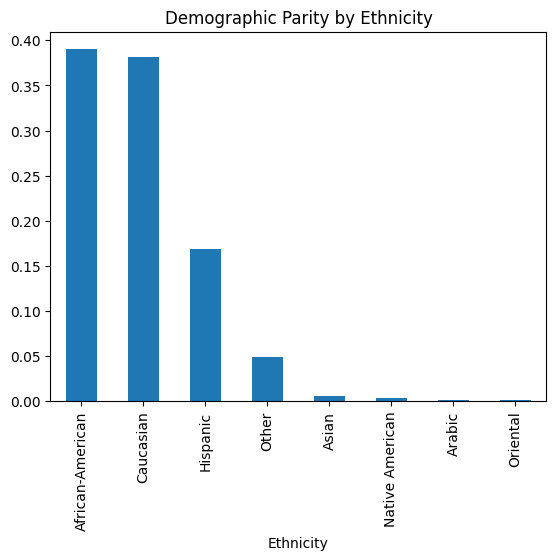

In [32]:
#Showing bar chart for demographic parity
import matplotlib.pyplot as plt

high_risk = compas_dataset[compas_dataset['DecileScore'] == 2]
high_risk['Ethnicity'].value_counts(normalize=True).plot(kind='bar')
plt.title('Demographic Parity by Ethnicity')
plt.show()

In [33]:
#Calculating false positive for each category
from sklearn.metrics import confusion_matrix

def false_positive_rate(group):

    cm = confusion_matrix(group["Actual"], group["Predicted"])

    if cm.shape[0] < 2:
        return 0

    FP = cm[0,1]
    TN = cm[0,0]

    return FP / (FP + TN) if (FP + TN) > 0 else 0


fpr = audit_df.groupby("Ethnicity").apply(false_positive_rate)

print("False Positive Rate:")
print(fpr)

False Positive Rate:
Ethnicity
African-American    0.0
Arabic              0.0
Asian               0.0
Caucasian           1.0
Hispanic            0.0
Native American     0.0
Oriental            0.0
Other               0.0
dtype: float64


/tmp/ipykernel_33832/582644894.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr = audit_df.groupby("Ethnicity").apply(false_positive_rate)


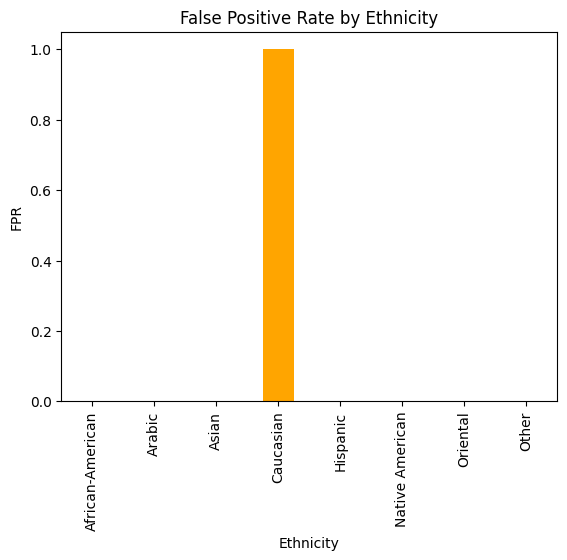

In [34]:
#visual representation of false positive
fpr.plot(kind="bar", color="orange")

plt.title("False Positive Rate by Ethnicity")
plt.ylabel("FPR")
plt.xlabel("Ethnicity")

plt.show()

## Visualization and Audit Dashboard​

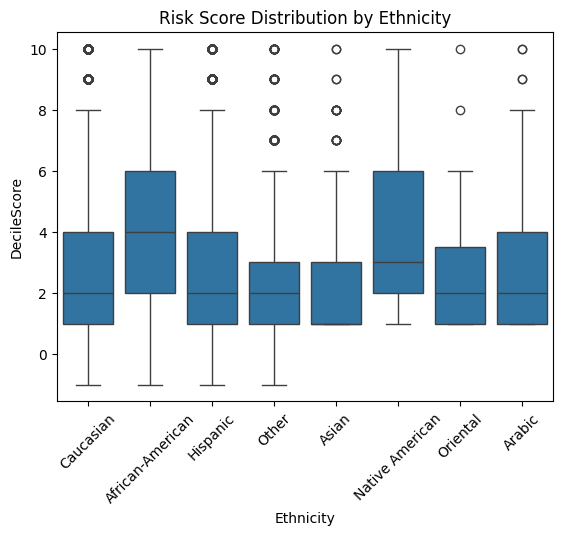

In [35]:
#calculating Risk score distribution
import seaborn as sns

sns.boxplot(x="Ethnicity", y="DecileScore", data=compas_dataset)

plt.title("Risk Score Distribution by Ethnicity")
plt.xticks(rotation=45)

plt.show()

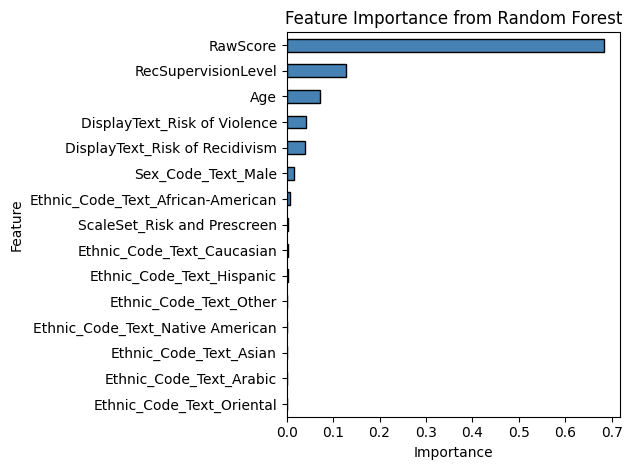

In [36]:
#Visual representation of the important features in the model
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

importance_df.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    color="steelblue",
    edgecolor="black",
    legend=False
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [37]:
#calculating the bias gap
bias_gap = demographic_parity.max() - demographic_parity.min()

print("Bias Gap:", round(bias_gap,3))

Bias Gap: 2.341


In [40]:
# Bias auditor report
def bias_audit_report(audit_df):

    parity = audit_df.groupby("Ethnicity")["Predicted"].mean()
    gap = parity.max() - parity.min()

    print("\nAI Bias Auditor Report")
    print("----------------------")

    print("\nDemographic Parity:")
    print(parity)

    print("\nBias Gap:", round(gap,3))

    if gap > 0.15:
        print("\n High Bias Detected")
    elif gap > 0.05:
        print("\n Moderate Bias")
    else:
        print("\n Low Bias")

In [41]:
bias_audit_report(audit_df)


AI Bias Auditor Report
----------------------

Demographic Parity:
Ethnicity
African-American    4.090418
Arabic              2.444444
Asian               2.301587
Caucasian           2.916498
Hispanic            2.720726
Native American     4.340909
Oriental            2.000000
Other               2.358779
Name: Predicted, dtype: float64

Bias Gap: 2.341

 High Bias Detected


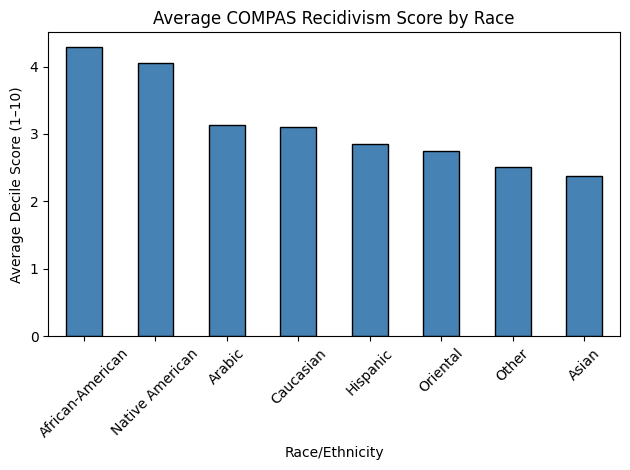

In [42]:
# Average COMPAS score per race
avg_score = compas_dataset.groupby('Ethnicity')['DecileScore'].mean().sort_values(ascending=False)
avg_score.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Average COMPAS Recidivism Score by Race')
plt.ylabel('Average Decile Score (1–10)')
plt.xlabel('Race/Ethnicity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

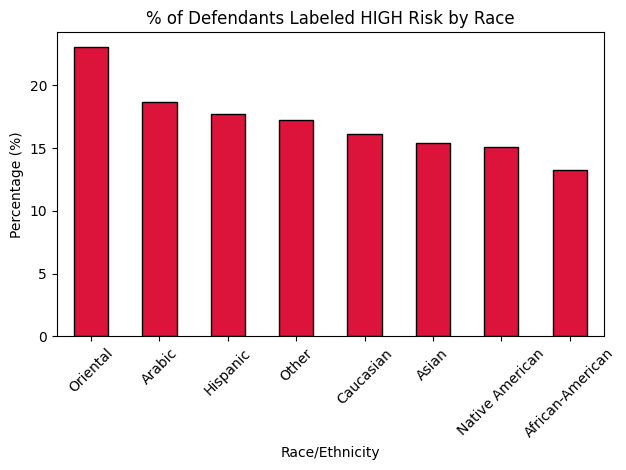

In [43]:
# What % of each race is labeled HIGH risk (score = 2 in your ordinal = "High")
high_risk_rate = compas_dataset[compas_dataset['DecileScore'] == 2].groupby('Ethnicity').size() / \
                 compas_dataset.groupby('Ethnicity').size() * 100

high_risk_rate.sort_values(ascending=False).plot(kind='bar', color='crimson', edgecolor='black')
plt.title('% of Defendants Labeled HIGH Risk by Race')
plt.ylabel('Percentage (%)')
plt.xlabel('Race/Ethnicity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

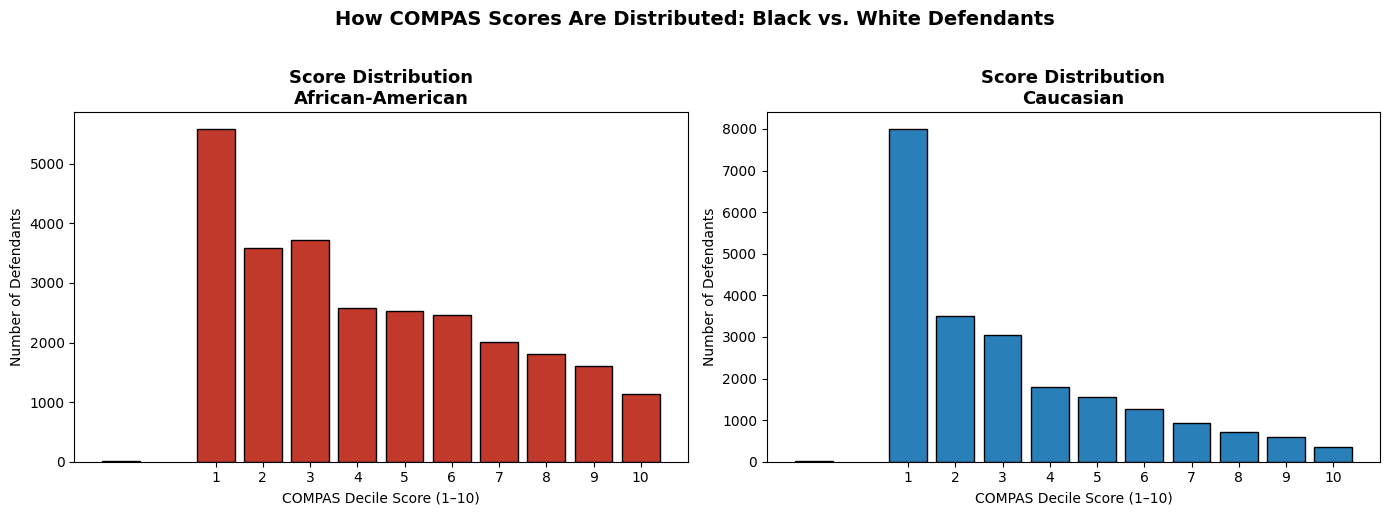

In [44]:
# Focus on just Black vs White for clarity
Ethnicity = ['African-American', 'Caucasian']
colors = ['#c0392b', '#2980b9']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, race in enumerate(Ethnicity):
    subset = compas_dataset[compas_dataset['Ethnicity'] == race]
    counts = subset['DecileScore'].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='black')
    axes[i].set_title(f'Score Distribution\n{race}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('COMPAS Decile Score (1–10)')
    axes[i].set_ylabel('Number of Defendants')
    axes[i].set_xticks(range(1, 11))

plt.suptitle('How COMPAS Scores Are Distributed: Black vs. White Defendants',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('score_distribution_race.png', dpi=150, bbox_inches='tight')
plt.show()

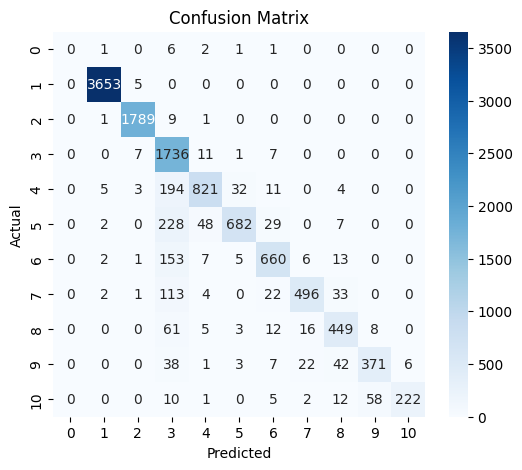

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

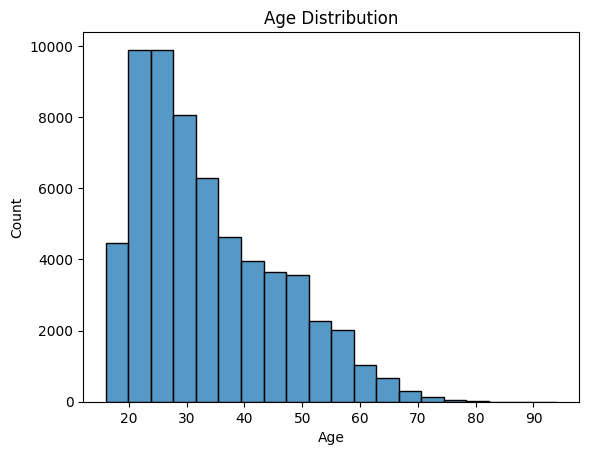

In [46]:
#Histogram for Age distribution
sns.histplot(compas_dataset["Age"], bins=20)

plt.title("Age Distribution")
plt.show()

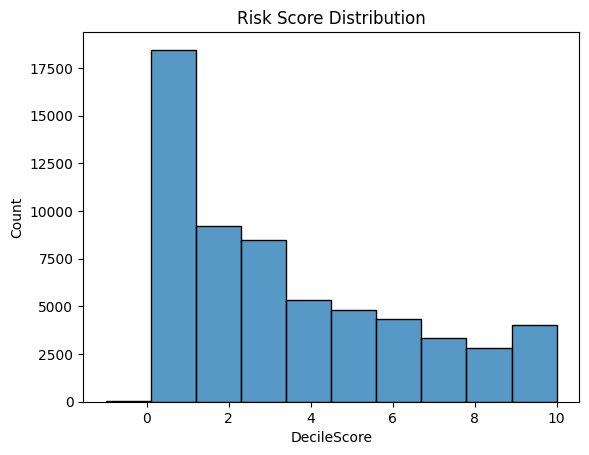

In [47]:
#Histogram for the decile score
sns.histplot(compas_dataset["DecileScore"], bins=10)

plt.title("Risk Score Distribution")
plt.show()

Ethnicity
African-American    42.917729
Arabic              31.333333
Asian               23.734568
Caucasian           31.082496
Hispanic            28.515214
Native American     40.502283
Oriental            27.435897
Other               25.100309
Name: Decile_Percentage, dtype: float64


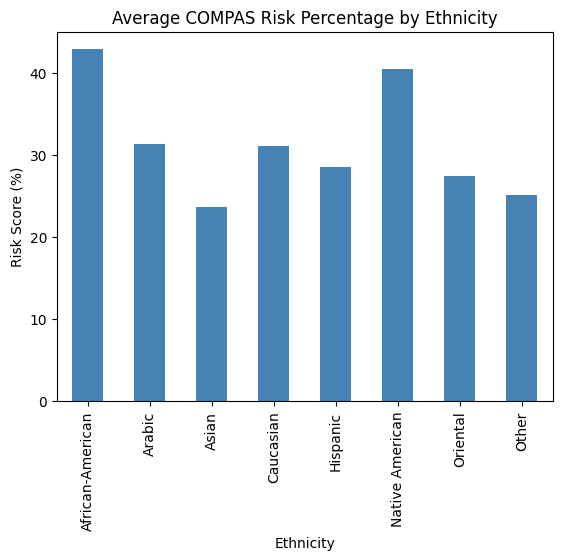

In [50]:
#Risk percentage per ethnicity
compas_dataset["Decile_Percentage"] = (compas_dataset["DecileScore"] / 10) * 100
ethnicity_percentage = compas_dataset.groupby("Ethnicity")["Decile_Percentage"].mean()
print(ethnicity_percentage)
import matplotlib.pyplot as plt

ethnicity_percentage.plot(kind="bar", color="steelblue")

plt.title("Average COMPAS Risk Percentage by Ethnicity")
plt.ylabel("Risk Score (%)")
plt.xlabel("Ethnicity")

plt.show()

/tmp/ipykernel_33832/4017272354.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ethnicities, rotation=45)


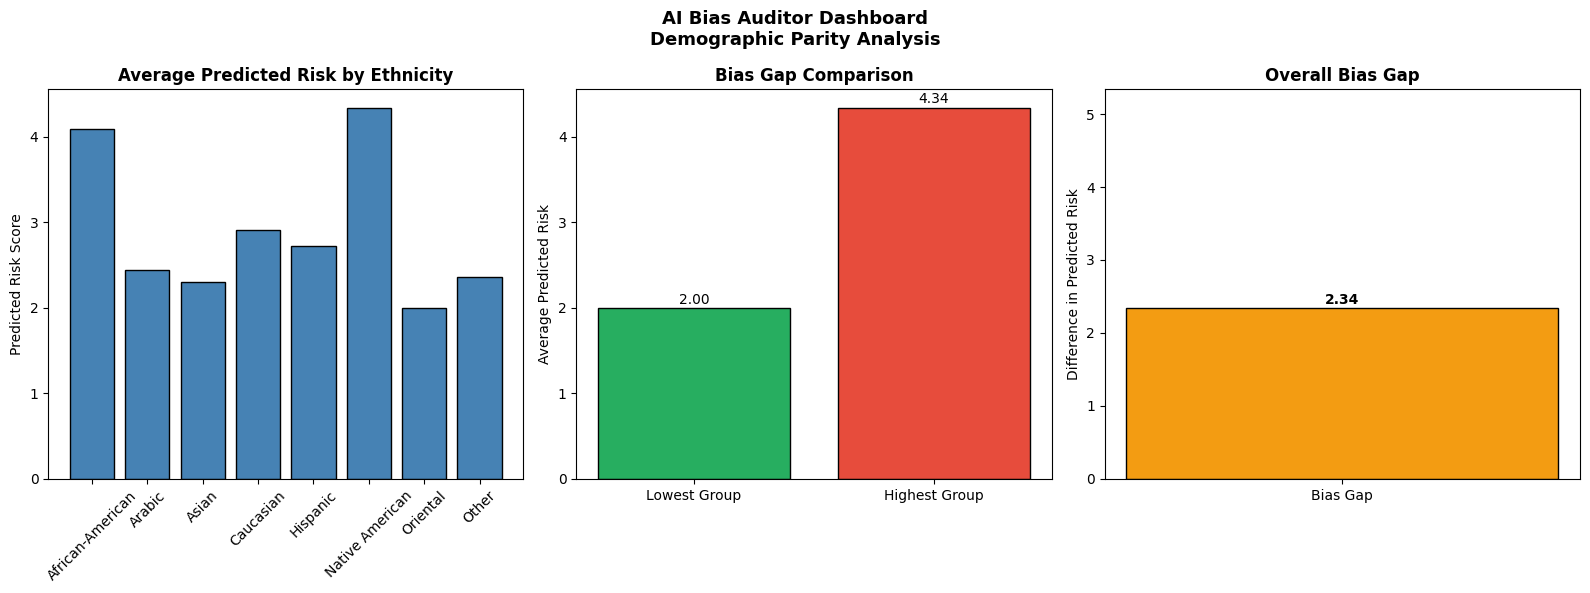

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# --- Calculate metrics from your results ---

# Average predicted score per ethnicity
demographic_parity = audit_df.groupby("Ethnicity")["Predicted"].mean()

# Convert to arrays for plotting
ethnicities = demographic_parity.index
avg_predictions = demographic_parity.values

# Bias gap
bias_gap = demographic_parity.max() - demographic_parity.min()

# For visualization purposes we compare highest vs lowest group
highest_group = demographic_parity.idxmax()
lowest_group = demographic_parity.idxmin()

highest_value = demographic_parity.max()
lowest_value = demographic_parity.min()

# --- Create figure ---
fig, axes = plt.subplots(1, 3, figsize=(16,6))

# ---------------------------------
# Chart 1: Average Prediction by Ethnicity
# ---------------------------------
axes[0].bar(ethnicities, avg_predictions,
            color="steelblue", edgecolor="black")

axes[0].set_title("Average Predicted Risk by Ethnicity",
                  fontweight="bold")
axes[0].set_ylabel("Predicted Risk Score")
axes[0].set_xticklabels(ethnicities, rotation=45)

# ---------------------------------
# Chart 2: Bias Gap Visualization
# ---------------------------------
axes[1].bar(["Lowest Group", "Highest Group"],
            [lowest_value, highest_value],
            color=["#27ae60", "#e74c3c"],
            edgecolor="black")

axes[1].set_title("Bias Gap Comparison",
                  fontweight="bold")
axes[1].set_ylabel("Average Predicted Risk")

axes[1].text(0, lowest_value + 0.05,
             f"{lowest_value:.2f}", ha="center")
axes[1].text(1, highest_value + 0.05,
             f"{highest_value:.2f}", ha="center")

# ---------------------------------
# Chart 3: Bias Score Gauge Style
# ---------------------------------
axes[2].bar(["Bias Gap"], [bias_gap],
            color="#f39c12", edgecolor="black")

axes[2].set_ylim(0, max(avg_predictions)+1)
axes[2].set_title("Overall Bias Gap", fontweight="bold")
axes[2].set_ylabel("Difference in Predicted Risk")

axes[2].text(0, bias_gap + 0.05,
             f"{bias_gap:.2f}",
             ha="center",
             fontweight="bold")

# ---------------------------------
plt.suptitle("AI Bias Auditor Dashboard\nDemographic Parity Analysis",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()